<a href="https://colab.research.google.com/github/Gayathri288/GenAI_LAB_231801039/blob/main/GenAI_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
!{sys.executable} -m pip uninstall -y gensim scipy smart_open
!{sys.executable} -m pip install gensim numpy matplotlib


Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: smart_open 7.5.1
Uninstalling smart_open-7.5.1:
  Successfully uninstalled smart_open-7.5.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.1/64.1 kB 4.0 MB/s eta 0:00:00


In [2]:
import gensim
import numpy as np
import matplotlib.pyplot as plt
import gensim.downloader as gdown
import random

In [3]:
print("Loading model... (takes time)")
model = gdown.load('word2vec-google-news-300')
print("Model loaded successfully!")


Loading model... (takes time)
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded successfully!


In [4]:
gender_target_words_A = ['male','man','boy','brother','he','him','his','son','father','husband']
gender_target_words_B = ['female','woman','girl','sister','she','her','hers','daughter','mother','wife']
gender_attribute_words_X = ['career','work','job','salary','office','business']
gender_attribute_words_Y = ['home','family','children','marriage','parent','baby']

In [5]:
race_target_words_A = ['white','caucasian','european','american']
race_target_words_B = ['black','african','kenya','nigeria']
race_attribute_words_X = ['pleasant','joy','love','peace','happy']
race_attribute_words_Y = ['unpleasant','pain','hate','war','sad']

In [6]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

In [7]:
def calculate_s_score(w, A, B, model):
    if w not in model:
        return 0.0

    w_vec = model[w]
    sim_A = [cosine_similarity(w_vec, model[a]) for a in A if a in model]
    sim_B = [cosine_similarity(w_vec, model[b]) for b in B if b in model]

    return np.mean(sim_A) - np.mean(sim_B)


In [8]:
def weat_effect_size(X, Y, A, B, model):
    s_X = [calculate_s_score(x, A, B, model) for x in X if x in model]
    s_Y = [calculate_s_score(y, A, B, model) for y in Y if y in model]

    diff = np.mean(s_X) - np.mean(s_Y)
    std = np.std(s_X + s_Y)

    return diff / std if std != 0 else 0

In [9]:
def permutation_test(X, Y, A, B, model, n=1000):
    observed = weat_effect_size(X, Y, A, B, model)
    combined = X + Y
    size = len(X)

    results = []
    for _ in range(n):
        random.shuffle(combined)
        X_p = combined[:size]
        Y_p = combined[size:]
        results.append(weat_effect_size(X_p, Y_p, A, B, model))

    p_value = np.mean([1 if abs(r) >= abs(observed) else 0 for r in results])
    return observed, p_value

In [10]:
gender_effect, gender_p = permutation_test(
    gender_target_words_A, gender_target_words_B,
    gender_attribute_words_X, gender_attribute_words_Y,
    model
)

print("Gender Effect Size:", round(gender_effect,4))
print("Gender P-value:", round(gender_p,4))


Gender Effect Size: 0.6919
Gender P-value: 0.136


In [11]:
race_effect, race_p = permutation_test(
    race_target_words_A, race_target_words_B,
    race_attribute_words_X, race_attribute_words_Y,
    model
)

print("Race Effect Size:", round(race_effect,4))
print("Race P-value:", round(race_p,4))


Race Effect Size: -0.8018
Race P-value: 0.355


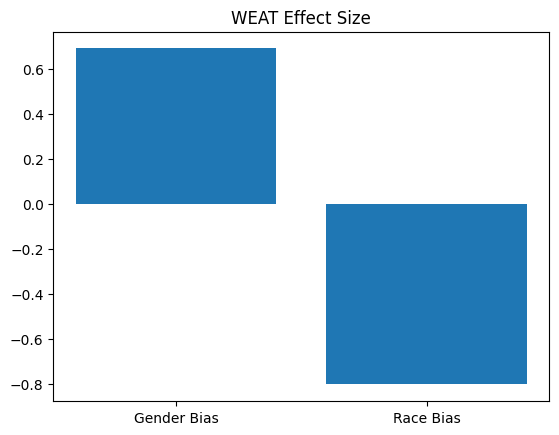

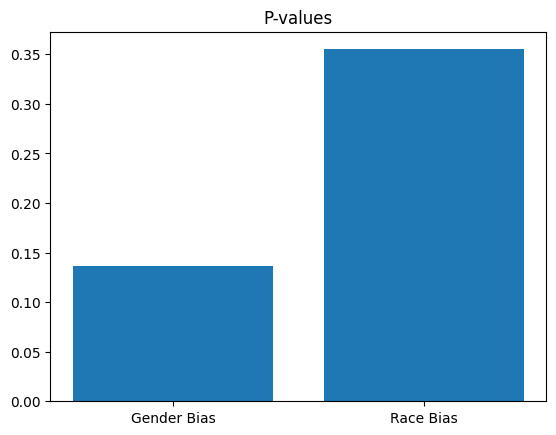

In [12]:
labels = ['Gender Bias', 'Race Bias']
effects = [gender_effect, race_effect]
pvals = [gender_p, race_p]

plt.figure()
plt.bar(labels, effects)
plt.title("WEAT Effect Size")
plt.show()

plt.figure()
plt.bar(labels, pvals)
plt.title("P-values")
plt.show()